# True Parameters at 1 PA Model

```python
m1 = 1e6
m2 = 10
a = 0.8 
e0 = 0.4 
xI0 = 1.0
dist = 0.4

qS = xp.pi/4
phiS = 1.0
qK = 1
phiK = xp.pi/3

Phi_phi0 = 0.9
Phi_theta0 = 0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.0

dev_0_p = 0.0
dev_0_e = 0.0
dev_1_p = 0.0
dev_1_e = 0.0
dev_2_p = 0.0
dev_2_e = 0.0

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included = True

p0 = 7.5

best_fit = [1.38157362e+01,9.99767738e+00,8.00145324e-01,7.49920154e+00,3.99929753e-01,7.85259004e-01,1.00036356e+00,9.70707228e-01, 3.41813443e-01,4.30235889e-04,6.22299020e-04]

# logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

best_fit = [1.38157362e+01,9.99767738e+00,8.00145324e-01,7.49920154e+00,3.99929753e-01,7.85259004e-01,1.00036356e+00,
            9.70707228e-01, 3.41813443e-01,4.30235889e-04,6.22299020e-04]
#logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]
logm1 = best_fit[0]
m1= np.exp(logm1)
m2 = best_fit[1]
a = best_fit[2]
p0= best_fit[3]
e0 = best_fit[4]
xI0 = 1.0
dist = 0.4
qS = best_fit[5]
phiS = best_fit[6]
qK = 1 
phiK = np.pi/3
Phi_phi0 = best_fit[7]
Phi_theta0 =0.5
Phi_r0 = best_fit[8]

dt = 10.0
T = 1.0

chi2 = 0.0

dev_0_p=best_fit[9]
dev_0_e=best_fit[10]
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [4]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000225.6674948048), 9.99767738, 0.800145324, 7.49920154, 0.399929753, 1.0, 0.4, 0.785259004, 1.00036356, 1, 1.0471975511965976, 0.970707228, 0.5, 0.341813443, 0.0, False, False, False, True, 0.000430235889, 0.00062229902, 0.0, 0.0, 0.0, 0.0)
SNR:  136.7767702001376


Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000225.6674948048), 9.99767738, 0.800145324, 7.49920154, 0.399929753, 1.0, 0.4, 0.785259004, 1.00036356, 1, 1.0471975511965976, 0.970707228, 0.5, 0.341813443, 0.0, False, False, False, True, 0.000430235889, 0.00062229902, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 136.7767702001376
calculating stable deltas...
Gamma_ii for m1: 22226.903634624097
Gamma_ii for m1: 22226.903682719654
Gamma_ii for m1: 22226.903539557086
Gamma_ii for m1: 22226.90361384841
Gamma_ii for m1: 22226.90359118095
Gamma_ii for m1: 22226.903591161674
Gamma_ii for m1: 22226.90358845835
Gamma_ii for m1: 22226.903589182584
Gamma_ii for m1: 22226.90361873163
Gamma_ii for m1: 22226.90361938957
Gamma_ii for m1: 22226.903675399943
Gamma_ii for m1: 22226.903595351923
Gamma_ii for m1: 22226.90439395979
Gamma_ii for m1: 22226.9045570063
Gamma_ii for m1: 22226.901710999027
Gamma_ii for m1: 22226

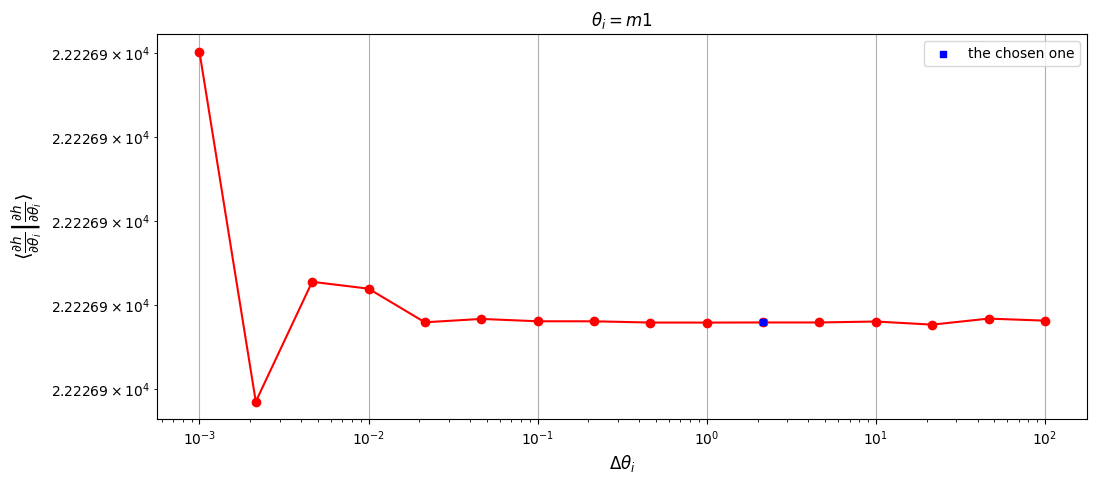

Gamma_ii for m2: 14186124790785.246
Gamma_ii for m2: 14186124617457.725
Gamma_ii for m2: 14186124707320.248
Gamma_ii for m2: 14186124678732.156
Gamma_ii for m2: 14186124676914.031
Gamma_ii for m2: 14186124682248.21
Gamma_ii for m2: 14186124674755.955
Gamma_ii for m2: 14186124657634.23
Gamma_ii for m2: 14186124765978.246
Gamma_ii for m2: 14186124665684.367
Gamma_ii for m2: 14186124813065.588
Gamma_ii for m2: 14186124587900.363
Gamma_ii for m2: 14186123745843.615
Gamma_ii for m2: 14186123362317.393
Gamma_ii for m2: 14186124391516.186
Gamma_ii for m2: 14186126697519.945
[np.float64(1.2218102276577688e-08), np.float64(6.334536407333965e-09), np.float64(2.0152150389411338e-09), np.float64(1.2816220366078895e-10), np.float64(3.7601387320209577e-10), np.float64(5.281397161768486e-10), np.float64(1.2069345943721835e-09), np.float64(7.637322906170621e-09), np.float64(7.069857432513379e-09), np.float64(1.0389110672943266e-08), np.float64(1.587221536186303e-08), np.float64(5.935777546657795e-08),

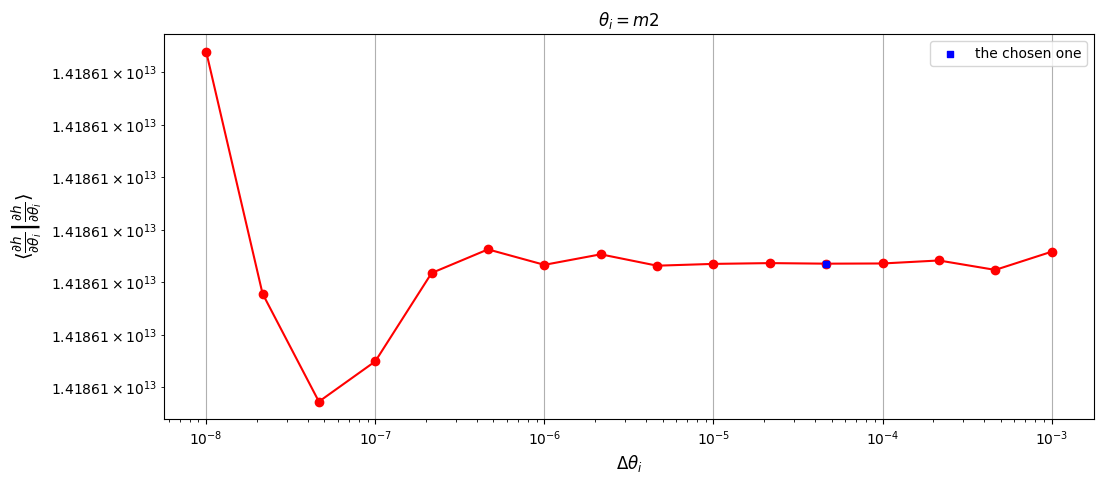

Gamma_ii for a: 1814701020848364.8
Gamma_ii for a: 1814701255847987.5
Gamma_ii for a: 1814701815577439.8
Gamma_ii for a: 1814701624401964.2
Gamma_ii for a: 1814701066712503.5
Gamma_ii for a: 1814696690332882.5
Gamma_ii for a: 1814705585528378.8
Gamma_ii for a: 1814712097613834.0
Gamma_ii for a: 1814717784436543.2
Gamma_ii for a: 1814684454832597.5
Gamma_ii for a: 1814675585985848.8
Gamma_ii for a: 1814186850137144.5
Gamma_ii for a: 1814003678871565.2
Gamma_ii for a: 1815063203350299.5
Gamma_ii for a: 1813780061800347.5
Gamma_ii for a: 1818339116336199.2
[np.float64(1.2949769114486426e-07), np.float64(3.0844155631810704e-07), np.float64(1.0534815912946678e-07), np.float64(3.0731753619360863e-07), np.float64(2.411631455721237e-06), np.float64(4.9017292761900165e-06), np.float64(3.5884950917629e-06), np.float64(3.1337229171508436e-06), np.float64(1.8366611262355592e-05), np.float64(4.887290498225263e-06), np.float64(0.00026939664382822737), np.float64(0.00010097623710068498), np.float64(0

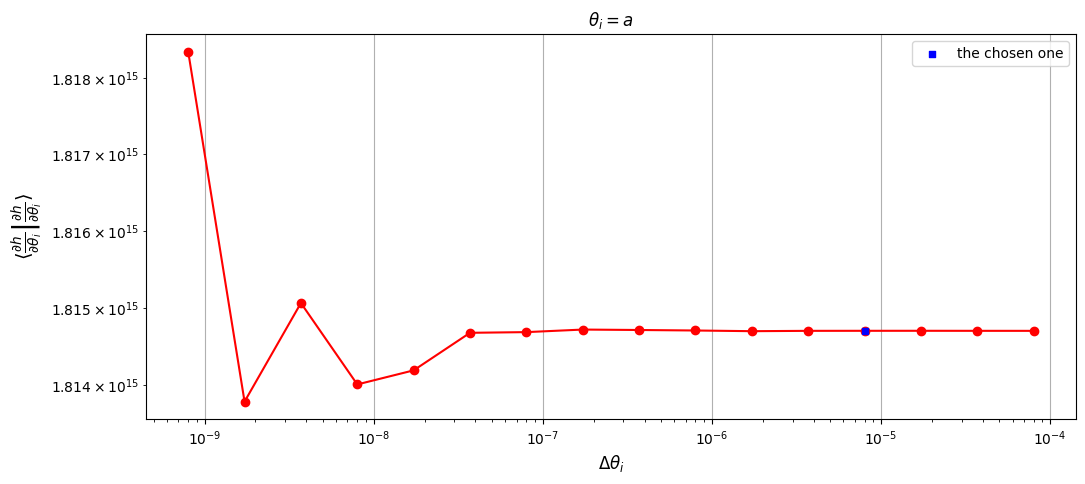

Gamma_ii for p0: 1172276638059111.2
Gamma_ii for p0: 1172276631272127.8
Gamma_ii for p0: 1172276660997916.8
Gamma_ii for p0: 1172276647566238.2
Gamma_ii for p0: 1172276712589053.2
Gamma_ii for p0: 1172276555362982.2
Gamma_ii for p0: 1172276893073070.8
Gamma_ii for p0: 1172277971885147.8
Gamma_ii for p0: 1172277172582489.2
Gamma_ii for p0: 1172275030811831.2
Gamma_ii for p0: 1172297524951509.8
Gamma_ii for p0: 1172303785301021.8
Gamma_ii for p0: 1172277467345370.0
Gamma_ii for p0: 1172278333202776.8
Gamma_ii for p0: 1172335502378490.8
Gamma_ii for p0: 1172180047178729.5
[np.float64(5.789575019195701e-09), np.float64(2.5357315375276268e-08), np.float64(1.1457771958424222e-08), np.float64(5.5467121628981836e-08), np.float64(1.3412028951761874e-07), np.float64(2.8808047867829955e-07), np.float64(9.202698531178192e-07), np.float64(6.818376039338562e-07), np.float64(1.8270206237496737e-06), np.float64(1.9188080841022363e-05), np.float64(5.340210950860728e-06), np.float64(2.2450278526078967e-

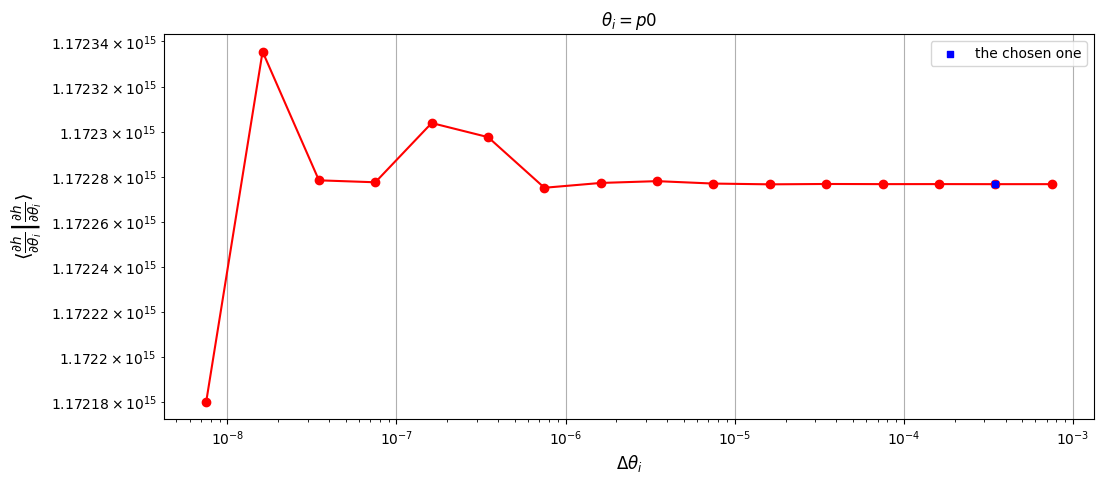

Gamma_ii for e0: 3812641328400490.0
Gamma_ii for e0: 3812640882299485.0
Gamma_ii for e0: 3812642240049028.0
Gamma_ii for e0: 3812641690651845.0
Gamma_ii for e0: 3812642750322241.5
Gamma_ii for e0: 3812643199991352.0
Gamma_ii for e0: 3812666305682809.0
Gamma_ii for e0: 3812602266493919.0
Gamma_ii for e0: 3812679337202150.0
Gamma_ii for e0: 3812699750584446.5
Gamma_ii for e0: 3812007278959649.5
Gamma_ii for e0: 3814325697669150.5
Gamma_ii for e0: 3812619988831519.0
Gamma_ii for e0: 3806412466436979.5
Gamma_ii for e0: 3823615289952165.5
Gamma_ii for e0: 3789790249921775.0
[np.float64(1.1700577598878051e-07), np.float64(3.5611774132328246e-07), np.float64(1.4409882374917583e-07), np.float64(2.7793592683459194e-07), np.float64(1.1794156623442235e-07), np.float64(6.060244879695028e-06), np.float64(1.6796713743993717e-05), np.float64(2.0214316866090454e-05), np.float64(5.354049264794807e-06), np.float64(0.00018165537841942036), np.float64(0.0006078187583503249), np.float64(0.00044738495906439

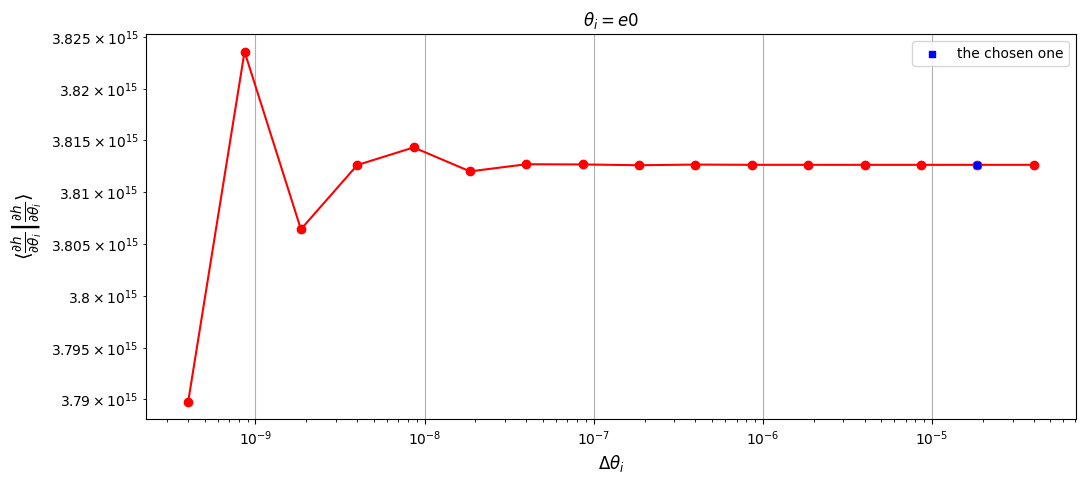

Gamma_ii for qS: 56562.60064067343
Gamma_ii for qS: 56562.60073662476
Gamma_ii for qS: 56562.60073683513
Gamma_ii for qS: 56562.6007368364
Gamma_ii for qS: 56562.60073683434
Gamma_ii for qS: 56562.60073683652
Gamma_ii for qS: 56562.60073683614
Gamma_ii for qS: 56562.60073683339
Gamma_ii for qS: 56562.600736857916
Gamma_ii for qS: 56562.60073679615
Gamma_ii for qS: 56562.600736842825
Gamma_ii for qS: 56562.600736953864
Gamma_ii for qS: 56562.60073710481
Gamma_ii for qS: 56562.60073642889
Gamma_ii for qS: 56562.60073782577
Gamma_ii for qS: 56562.600739484675
[np.float64(1.6963740349554672e-09), np.float64(3.719237795971549e-12), np.float64(2.2511209984955088e-14), np.float64(3.640384243281441e-14), np.float64(3.846201020286604e-14), np.float64(6.6890452526724e-15), np.float64(4.862421356750558e-14), np.float64(4.336302220528842e-13), np.float64(1.0919866374995413e-12), np.float64(8.251966403055456e-13), np.float64(1.963106146169635e-12), np.float64(2.6686717848323546e-12), np.float64(1.1

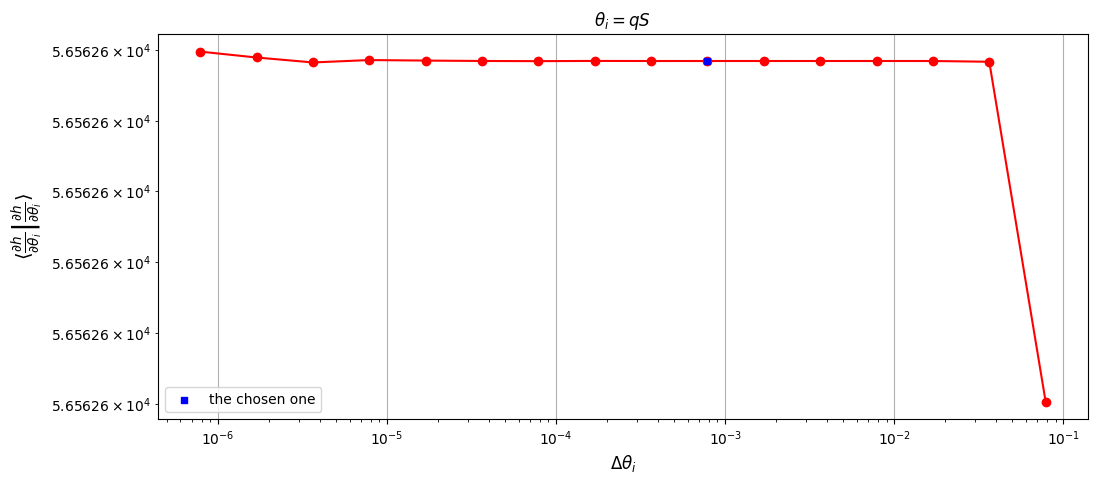

Gamma_ii for phiS: 1108149.9357180567
Gamma_ii for phiS: 1108149.9356814846
Gamma_ii for phiS: 1108149.9356814038
Gamma_ii for phiS: 1108149.9356814036
Gamma_ii for phiS: 1108149.9356814038
Gamma_ii for phiS: 1108149.9356814036
Gamma_ii for phiS: 1108149.9356814036
Gamma_ii for phiS: 1108149.9356814038
Gamma_ii for phiS: 1108149.9356814045
Gamma_ii for phiS: 1108149.9356814027
Gamma_ii for phiS: 1108149.9356814034
Gamma_ii for phiS: 1108149.935681399
Gamma_ii for phiS: 1108149.9356814064
Gamma_ii for phiS: 1108149.9356814008
Gamma_ii for phiS: 1108149.9356814031
Gamma_ii for phiS: 1108149.9356813934
[np.float64(3.300285007017962e-11), np.float64(7.29073122205376e-14), np.float64(2.101075280130767e-16), np.float64(2.1010752801307664e-16), np.float64(2.101075280130767e-16), np.float64(0.0), np.float64(2.1010752801307664e-16), np.float64(6.303225840392295e-16), np.float64(1.6808602241046149e-15), np.float64(6.303225840392302e-16), np.float64(3.992043032248474e-15), np.float64(6.7234408964

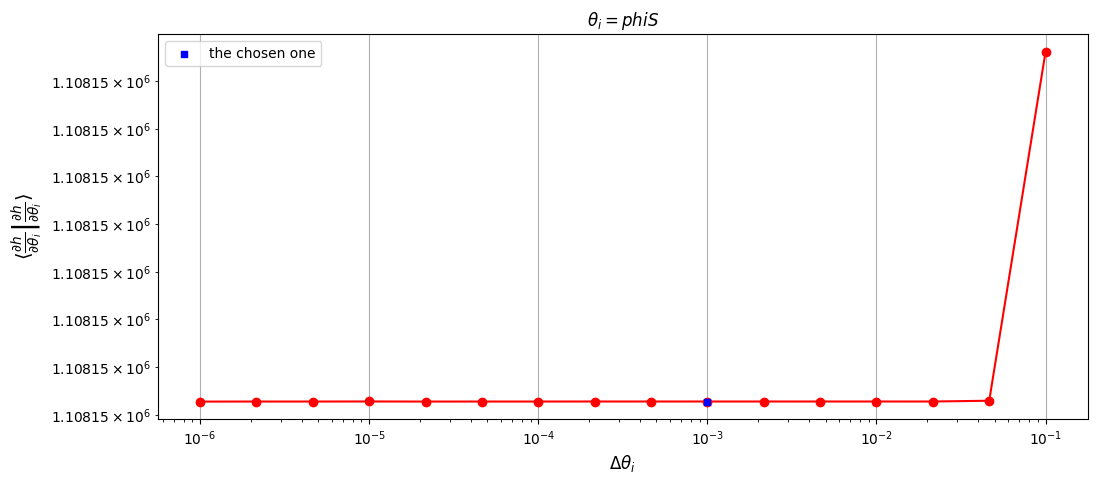

Gamma_ii for dev0p: 1158420976969546.8
Gamma_ii for dev0p: 1158421230700699.2
Gamma_ii for dev0p: 1158421099604052.0
Gamma_ii for dev0p: 1158420949757310.5
Gamma_ii for dev0p: 1158422156336243.0
Gamma_ii for dev0p: 1158427733854623.8
Gamma_ii for dev0p: 1158419577122145.5
Gamma_ii for dev0p: 1158415298536751.2
Gamma_ii for dev0p: 1158410763078361.0
Gamma_ii for dev0p: 1158387966013173.0
Gamma_ii for dev0p: 1158266445488092.2
Gamma_ii for dev0p: 1158097346694540.8
Gamma_ii for dev0p: 1160545795437472.8
Gamma_ii for dev0p: 1157068928518494.5
Gamma_ii for dev0p: 1156626641703281.8
Gamma_ii for dev0p: 1159314004945623.5
[np.float64(2.1903185626745164e-07), np.float64(1.1316838694910581e-07), np.float64(1.293543090112389e-07), np.float64(1.0415710075125488e-06), np.float64(4.814731396486013e-06), np.float64(7.041259177019193e-06), np.float64(3.693481430756726e-06), np.float64(3.915241928689847e-06), np.float64(1.9679991381868995e-05), np.float64(0.00010491586418144176), np.float64(0.0001460

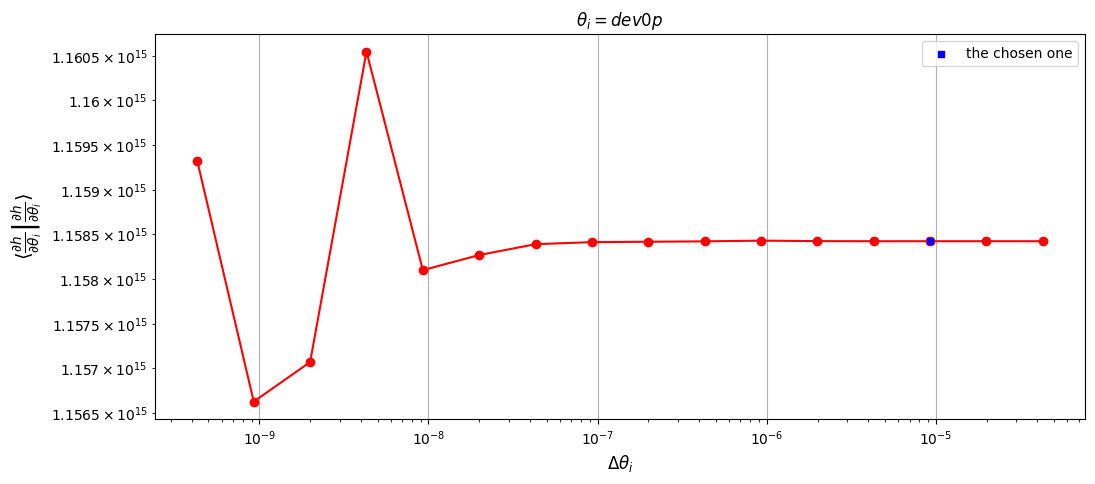

Gamma_ii for dev0e: 14290826037359.113
Gamma_ii for dev0e: 14290857931419.652
Gamma_ii for dev0e: 14290833982473.06
Gamma_ii for dev0e: 14290894510737.617
Gamma_ii for dev0e: 14290797764599.857
Gamma_ii for dev0e: 14290876828895.945
Gamma_ii for dev0e: 14291916322269.08
Gamma_ii for dev0e: 14290813706440.85
Gamma_ii for dev0e: 14290373187686.457
Gamma_ii for dev0e: 14293573574117.121
Gamma_ii for dev0e: 14288986521104.057
Gamma_ii for dev0e: 14270781185803.22
Gamma_ii for dev0e: 14258312281607.49
Gamma_ii for dev0e: 14084420452359.39
Gamma_ii for dev0e: 14412604770053.088
Gamma_ii for dev0e: 13636933339114.771
[np.float64(2.2317806734990155e-06), np.float64(1.6758256810742446e-06), np.float64(4.23544268073367e-06), np.float64(6.7698206463615515e-06), np.float64(5.5325014017351105e-06), np.float64(7.27329596462211e-05), np.float64(7.715556656746015e-05), np.float64(3.08262596509487e-05), np.float64(0.00022390386939060076), np.float64(0.00032102017916313554), np.float64(0.001275706989253

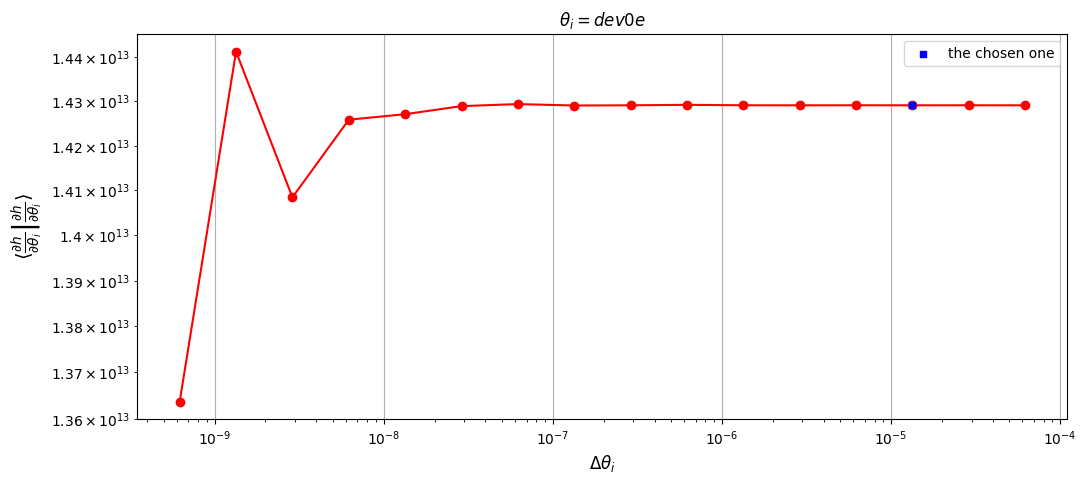

stable deltas: {'m1': 2.1549208759111056, 'm2': 4.640510768907105e-05, 'a': 8.001453239999997e-06, 'p0': 0.00034808210129075746, 'e0': 1.8563094757543177e-05, 'qS': 0.0007852590039999999, 'phiS': 0.00100036356, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 9.269151241583058e-06, 'dev0e': 1.3407025962608452e-05}
Time taken to compute stable deltas is 306.2792856693268 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is not positive semi-definite. Try lowering inspiral error tolerance or increasing the derivative order.
Time taken to compute FM is 20.86817717552185 seconds


In [5]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [6]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher[-1], m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(1e6), 10, 0.8, 7.5, 0.4, np.pi/4, 1.0,  0.9,0.4,0,0])

In [7]:
pd.DataFrame(fisher_)

,0,1,2,3,4,5,6,7,8,9,10
0,2.223694e+16,-5.492070e+14,5.986673e+15,5.096338e+15,8.875684e+15,-2.872347e+10,1.333579e+11,-3.495535e+10,-1.303969e+10,-4.928082e+15,-5.605199e+14
1,-5.492070e+14,1.418612e+13,-1.580362e+14,-1.273195e+14,-2.064066e+14,6.444628e+08,-2.991242e+09,7.840026e+08,2.310020e+08,1.281285e+14,1.364310e+13
2,5.986673e+15,-1.580362e+14,1.814702e+15,1.401456e+15,2.187700e+15,-6.999120e+09,3.248885e+10,-8.515092e+09,-1.689080e+09,-1.432451e+15,-1.469119e+14
3,5.096338e+15,-1.273195e+14,1.401456e+15,1.172277e+15,2.005259e+15,-6.479435e+09,3.008195e+10,-7.884880e+09,-2.715508e+09,-1.144477e+15,-1.279140e+14
4,8.875684e+15,-2.064066e+14,2.187700e+15,2.005259e+15,3.812641e+15,-1.294893e+10,6.013983e+10,-1.576480e+10,-7.186170e+09,-1.835667e+15,-2.270975e+14
5,-2.872347e+10,6.444628e+08,-6.999120e+09,-6.479435e+09,-1.294893e+10,5.656260e+04,-2.377610e+05,6.233418e+04,2.877504e+04,5.714272e+09,7.262931e+08
6,1.333579e+11,-2.991242e+09,3.248885e+10,3.008195e+10,6.013983e+10,-2.377610e+05,1.108150e+06,-2.896649e+05,-1.336994e+05,-2.652152e+10,-3.372074e+09
7,-3.495535e+10,7.840026e+08,-8.515092e+09,-7.884880e+09,-1.576480e+10,6.233418e+04,-2.896649e+05,7.594850e+04,3.504685e+04,6.951216e+09,8.838769e+08
8,-1.303969e+10,2.310020e+08,-1.689080e+09,-2.715508e+09,-7.186170e+09,2.877504e+04,-1.336994e+05,3.504685e+04,3.658368e+04,1.968464e+09,3.401146e+08
9,-4.928082e+15,1.281285e+14,-1.432451e+15,-1.144477e+15,-1.835667e+15,5.714272e+09,-2.652152e+10,6.951216e+09,1.968464e+09,1.158421e+15,1.220540e+14


In [8]:
from scipy.stats import chi2
def plot_confidence_ellipse(ax, mean, cov, i, j, levels=[0.90, 0.99]):

    # Extract 2x2 sub-covariance
    cov2 = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2*np.pi, 400)

    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        
        ellipse = np.vstack([r1*np.cos(theta), r2*np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]

        ax.plot(ellipse[0], ellipse[1], label=f"{int(p*100)}%", lw=1)


# --------------------------------------------------------------------
# Main triangle plot function (WITH LEGEND)
# --------------------------------------------------------------------
def triangle_plot(best_fit, cov, param_truth=None, labels=None,levels=[0.90, 0.99]):
    D = len(best_fit)
    if labels is None:
        labels = [f"p{i}" for i in range(D)]

    fig, axes = plt.subplots(D, D, figsize=(2.2*D, 2.2*D))
    
    legend_ax = axes[-1, -1]  # bottom-right panel for legend only
    legend_handles = []       # store handles for legend

    for i in range(D):
        for j in range(D):

            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            # ==========================
            # Diagonal panels
            # ==========================
            if i == j:
                ax.axis("off")
                continue
                sigma = np.sqrt(cov[i, i])
                x = np.linspace(best_fit[i] - 4*sigma,
                                best_fit[i] + 4*sigma, 300)
                y = np.exp(-0.5*((x - best_fit[i])/sigma)**2)

                ax.plot(x, y, lw=1.5)

                if param_truth is not None:
                    line_truth = ax.axvline(param_truth[i], color='red', linestyle='--', lw=1)

                ax.set_yticks([])
                ax.set_xlabel(labels[i])

            # ==========================
            # Off-diagonal panels
            # ==========================
            else:
                # Ellipses
                plot_confidence_ellipse(ax, best_fit, cov, j, i,levels=levels)

                # Best-fit point
                bestfit_handle = ax.scatter(best_fit[j], best_fit[i],
                                            color="black", s=12, label="Best-fit")

                # Truth point
                if param_truth is not None:
                    truth_handle = ax.scatter(param_truth[j], param_truth[i],
                                              color="red", marker="x", s=30,
                                              label="Param truth")

                ax.set_xlabel(labels[j])
                ax.set_ylabel(labels[i])

                # Collect handles only once (avoid duplicates)
                if i == D - 1 and j == 0:
                    # ellipse handles (match levels dynamically)
                    level_labels = {f"{int(p*100)}%" for p in levels}
                    for item in ax.get_lines():
                        if item.get_label() in level_labels:
                            legend_handles.append(item)
                
                    legend_handles.append(bestfit_handle)
                    if param_truth is not None:
                        legend_handles.append(truth_handle)

    # Add the legend to bottom-right subplot
    legend_ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    legend_ax.axis("off")  # hide this subplot except for legend

    plt.tight_layout()
    plt.show()


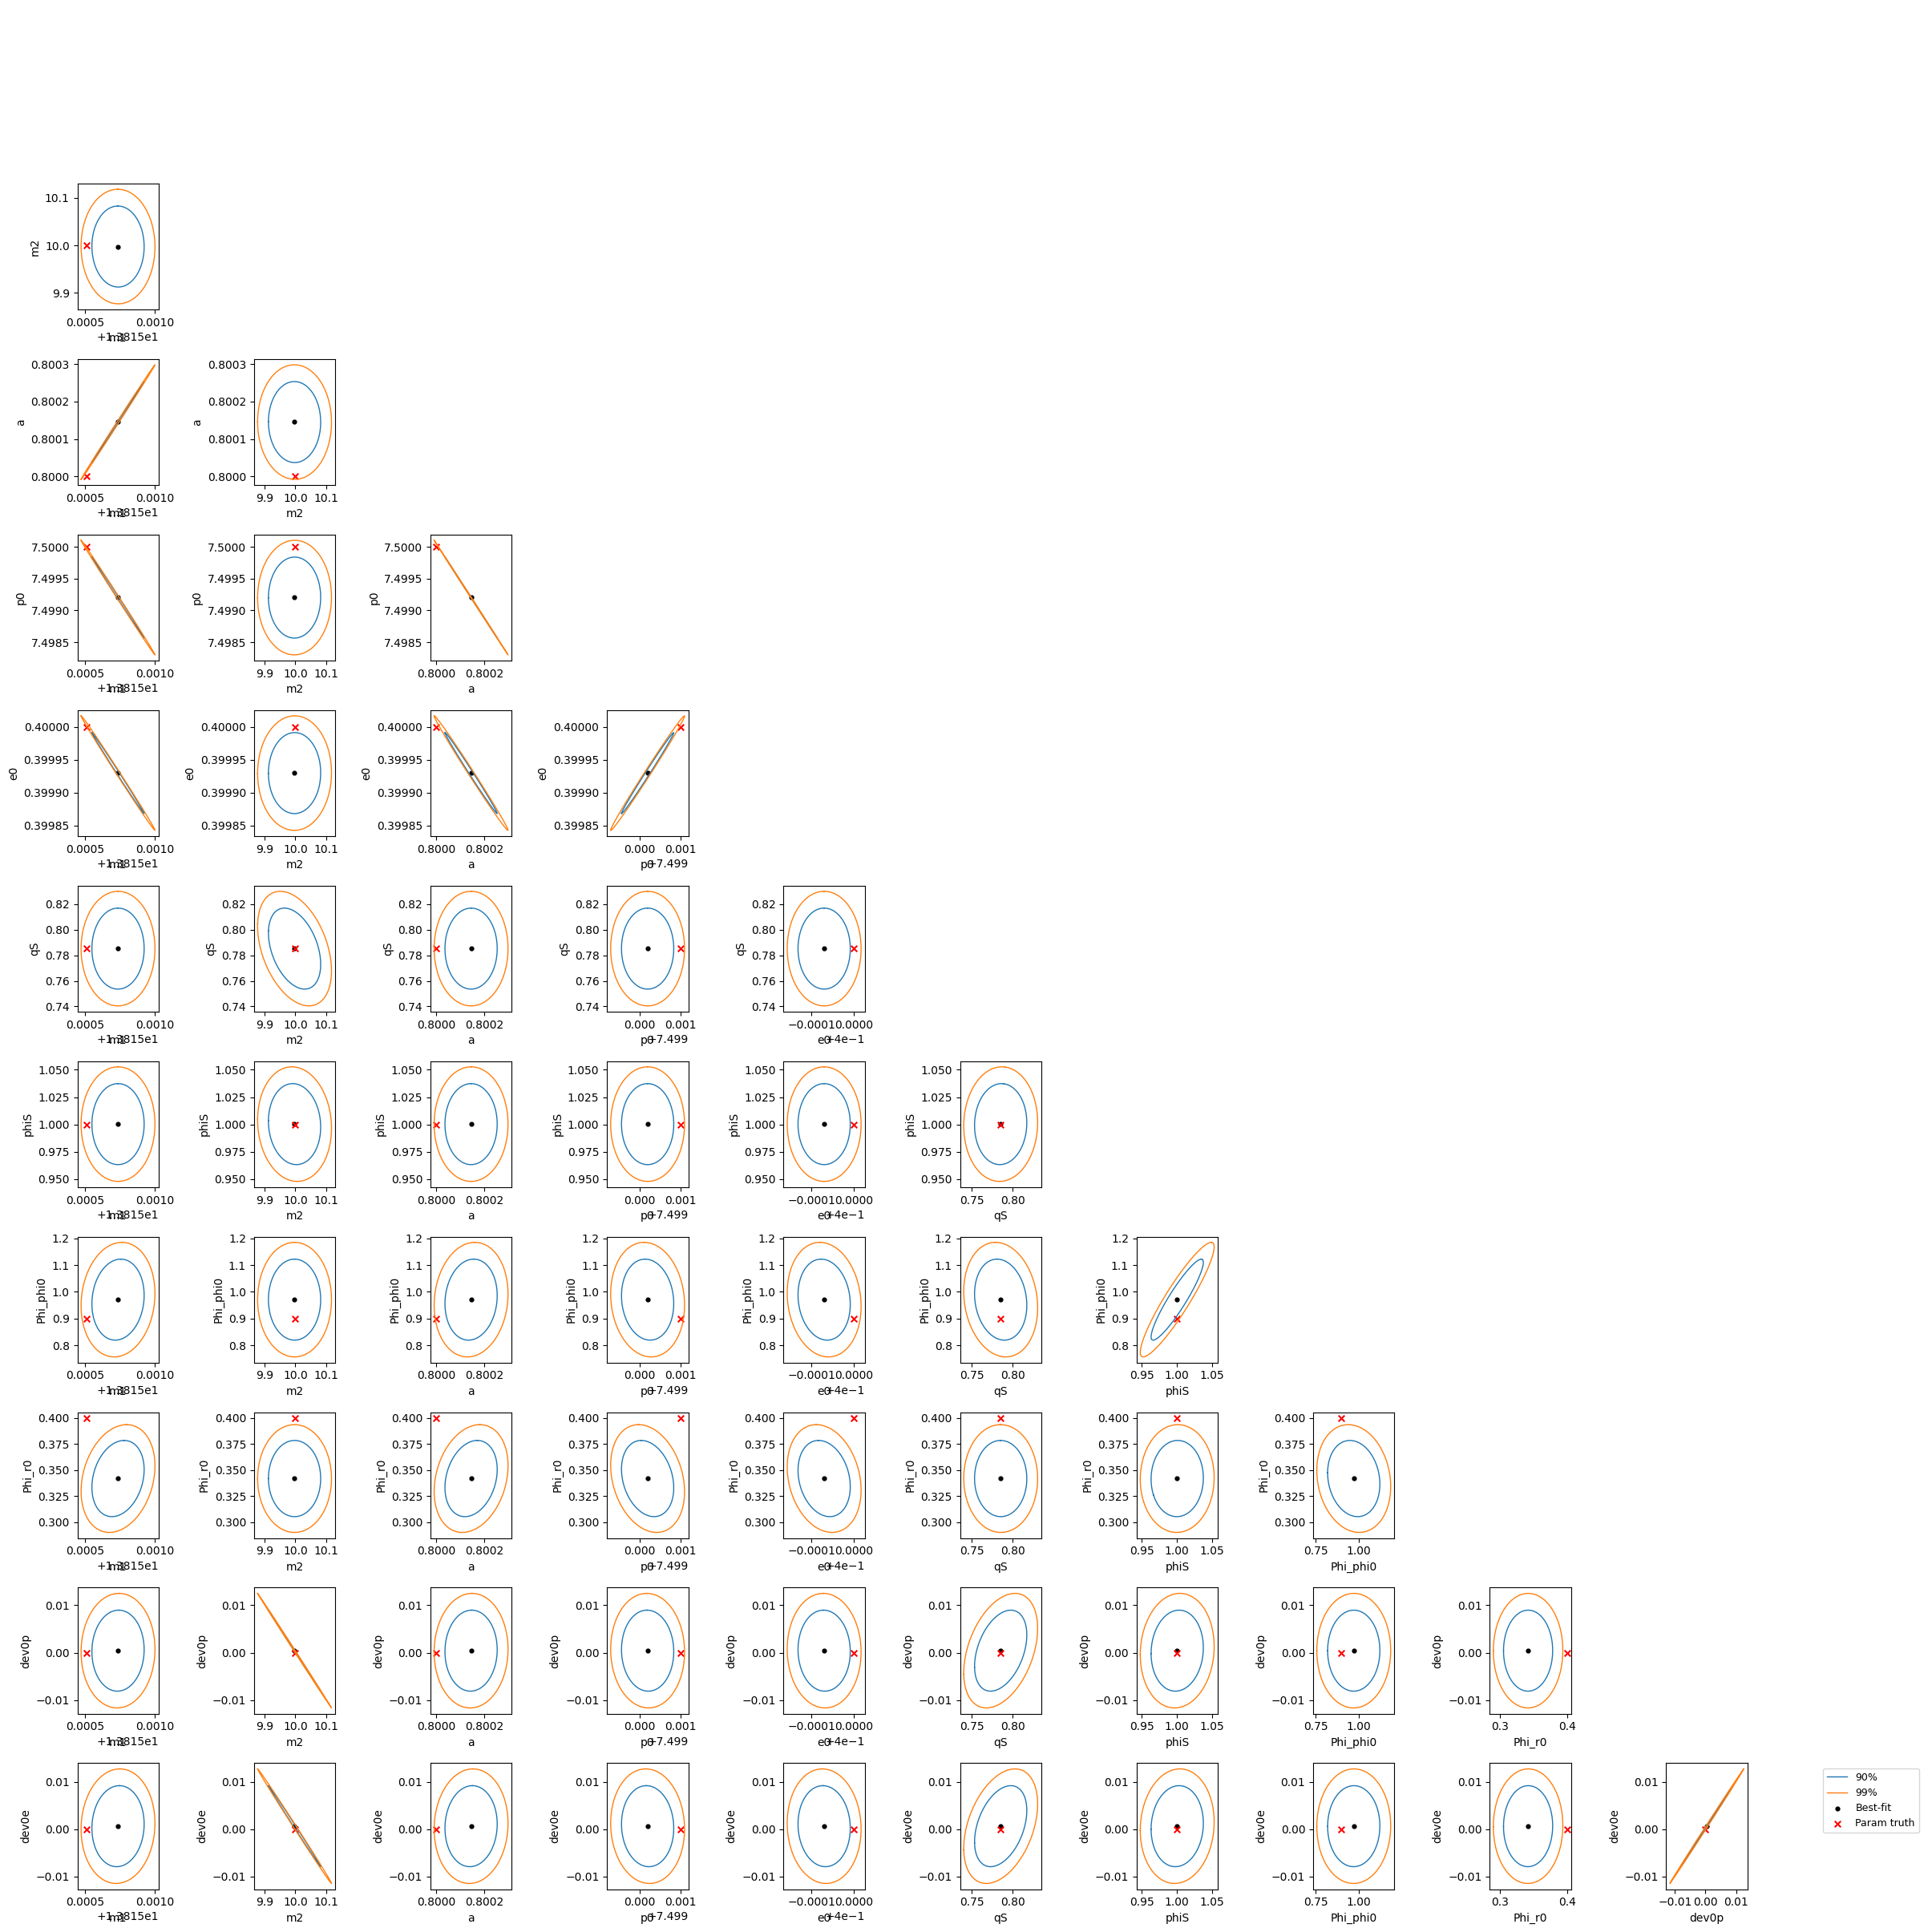

In [9]:
labels = param_names
triangle_plot(np.array(best_fit), cov, np.array(params_truth_in), labels,levels=[0.90, 0.99])


In [10]:
# True waveform with 1PA order
m1_true = 1e6
m2_true = 10
a_true = 0.8 
e0_true = 0.4 
xI0_true = 1.0
dist_true = 0.4
qS_true = xp.pi/4
phiS_true = 1.0
qK_true = 1 
phiK_true = xp.pi/3
Phi_phi0_true = 0.9
Phi_theta0_true =0.5
Phi_r0_true = 0.4
p0_true=7.5
chi2 = 0.0
dev_0_p_true=0.0
dev_0_e_true=0.0

evolve_1PA_true = True
evolve_primary = False
evolve_2PA = False
deviation_included=True

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)

add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_true = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)
fisher_derivs = xp.array(Fisher[0])
fisher_exact = xp.array(Fisher[-1])




In [11]:
# baseline check - 0PA model at true parameters
evolve_1PA_approx = False
add_args = [chi2, evolve_1PA_approx, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_approx = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_approx= xp.asarray(waveform_approx)

In [12]:
# waveform at best fit parameters with 0PA calaculated during fisher calculation
waveform_best_fit=sef.waveform
waveform_best_fit= xp.asarray(waveform_best_fit)

# waveform analysis and p0 evolution 

In [13]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p_sep = get_separatrix(a_true, e0_true, xI0_true)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1_true, m2_true, a_true, e0_true, xI0_true, *add_args])
print('should take p0 around for for true waveform: ', p0_should)
print('separatrix p: ', p_sep)

should take p0 around for for true waveform:  7.406738026385176
separatrix p:  3.3636344376256564


# P evolution is done considering true waveform (1PA)

[0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


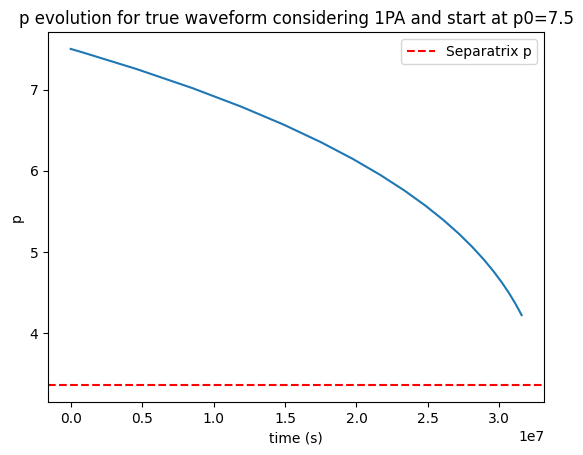

In [14]:
from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, *add_args,
                                               Phi_phi0=Phi_phi0_true, Phi_theta0=Phi_theta0_true, Phi_r0=Phi_r0_true, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA and start at p0=7.5')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()

# Waveform Visualization

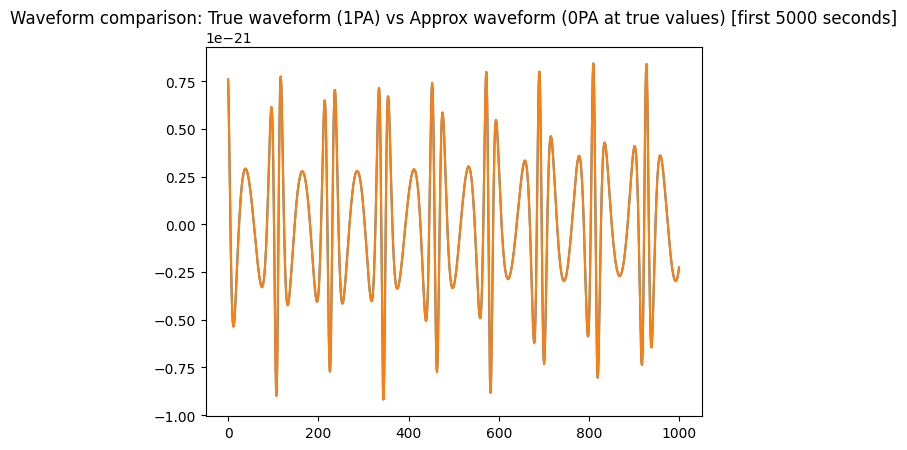

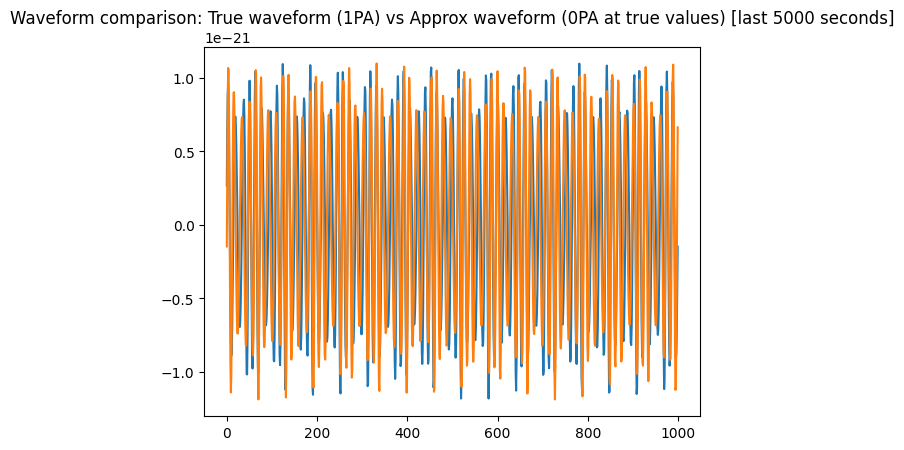

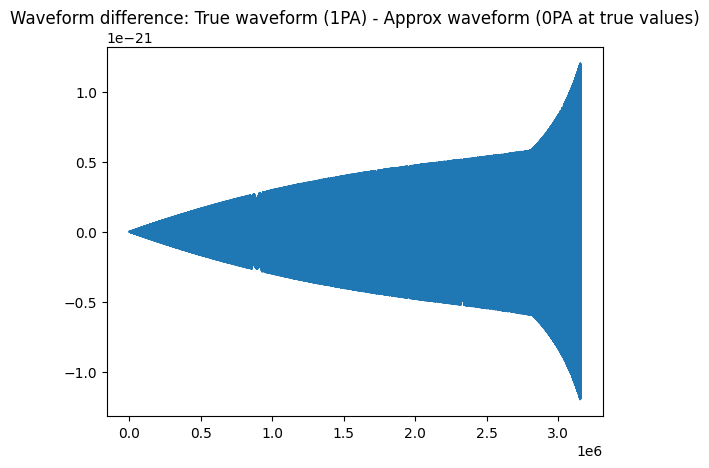

In [15]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_approx[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_approx[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_approx[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at true values)')
plt.show()

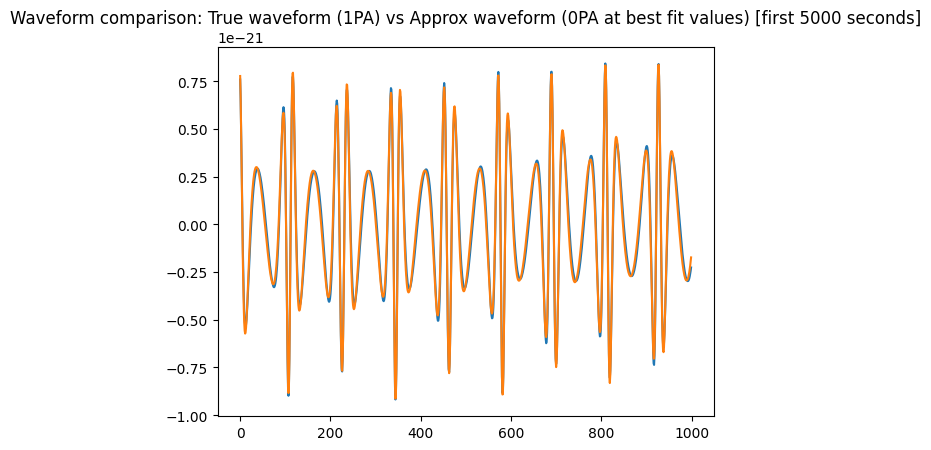

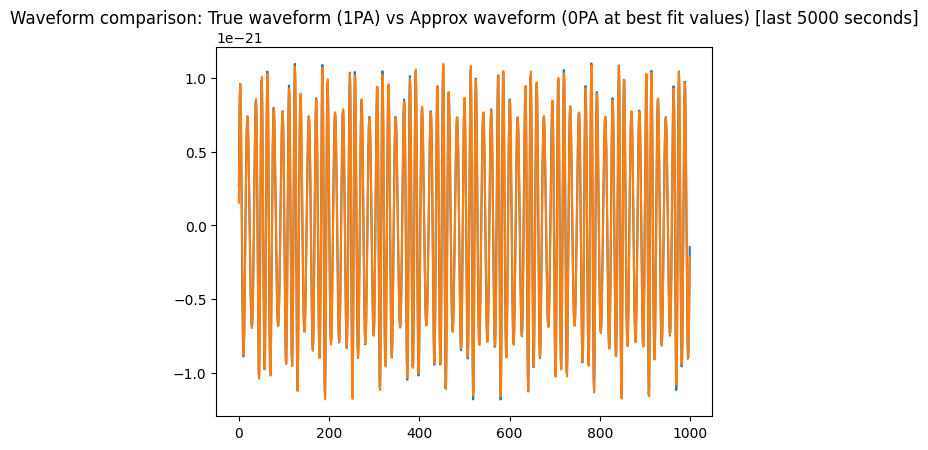

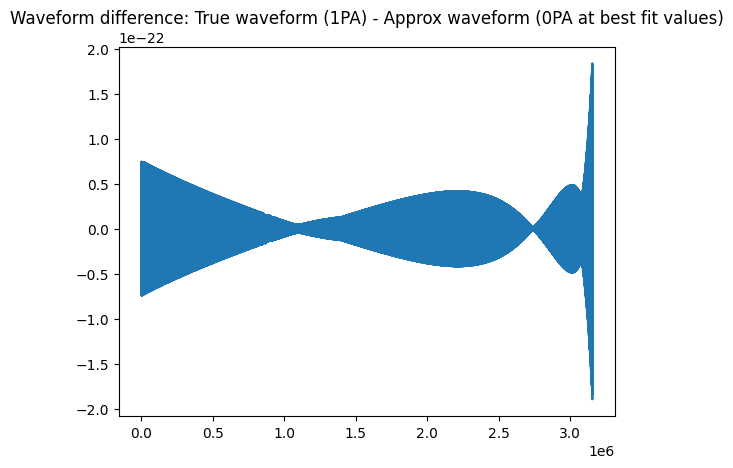

In [16]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_best_fit[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_best_fit[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_best_fit[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at best fit values)')
plt.show()

# Overlap and mismatch

In [17]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner_bf=inner_product(waveform_best_fit,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_bf=np.sqrt(inner_product(waveform_best_fit,waveform_best_fit,PSD,dt,use_gpu=use_gpu))
overlap_bf=diff_inner_bf/((norm_true)*norm_bf)
print("overlap between best fit point and true waveform:", overlap_bf)
print("mismatch between best fit point and true waveform:", 1-overlap_bf)

norm_approx=np.sqrt(inner_product(waveform_approx,waveform_approx,PSD,dt,use_gpu=use_gpu))
diff_inner_approx=inner_product(waveform_approx,waveform_true,PSD,dt,use_gpu=use_gpu)
overlap_approx=diff_inner_approx/((norm_true)*norm_approx)
print("overlap between approximate waveform and true waveform (both at true points)", overlap_approx)
print("mismatch between approximate waveform and true waveform (both at true points):", 1-overlap_approx)

overlap between best fit point and true waveform: 0.9994405017443316
mismatch between best fit point and true waveform: 0.000559498255668367
overlap between approximate waveform and true waveform (both at true points) 0.9005241196983437
mismatch between approximate waveform and true waveform (both at true points): 0.09947588030165633


# table true vs bias

In [18]:
best_fit


[13.8157362,
 9.99767738,
 0.800145324,
 7.49920154,
 0.399929753,
 0.785259004,
 1.00036356,
 0.970707228,
 0.341813443,
 0.000430235889,
 0.00062229902]

In [21]:
import pandas as pd
best_fit_ = best_fit.copy()
best_fit_[0] = np.exp(best_fit[0])
truue_param=[m1_true,m2_true,a_true,p0_true,e0_true,qS_true,phiS_true,Phi_phi0_true,Phi_r0_true,dev_0_p_true,dev_0_e_true]
df = pd.DataFrame({'Best Fit': best_fit_, 'True Param': truue_param}, index=param_names)
print(df)

              Best Fit      True Param
m1        1.000226e+06  1000000.000000
m2        9.997677e+00       10.000000
a         8.001453e-01        0.800000
p0        7.499202e+00        7.500000
e0        3.999298e-01        0.400000
qS        7.852590e-01        0.785398
phiS      1.000364e+00        1.000000
Phi_phi0  9.707072e-01        0.900000
Phi_r0    3.418134e-01        0.400000
dev0p     4.302359e-04        0.000000
dev0e     6.222990e-04        0.000000


In [20]:
# #Orthoganal check between derivative and exact fisher matrices
# PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
#                 noise_PSD=get_sensitivity,
#                 noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
#                 channels=["A","E"])
# inner_val = []
# for i in range(fisher_derivs.shape[0]):
#     temp_deriv = inner_product(fisher_derivs[i],waveform_true-sef.waveform, PSD=PSD, dt=dt,use_gpu=use_gpu)
#     inner_val.append(temp_deriv)
